<a href="https://colab.research.google.com/github/M4XJUNG/AIF-Financial-Time-Series/blob/main/Replication_Hwang(2021)_KOSPI_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 필수 라이브러리 설치
''' 코스피 방향 예측을 위한 하이브리드 머신러닝 모델
https://dbpia.co.kr/pdf/cpViewer?nodeId=NODE10659809

'''
!pip install -q yfinance xgboost

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# ---------------------------------------------------------
# Step 1. 데이터 수집 (Data Collection)
# ---------------------------------------------------------
print("1. Yahoo Finance에서 KOSPI 200 데이터를 다운로드합니다...")
# progress=False로 지저분한 로딩바 제거
df = yf.download('^KS200', start='2010-01-01', progress=False)

# [핵심 수정 사항] MultiIndex 문제 해결
# yfinance가 컬럼을 ('Close', '^KS200') 형태로 가져오는 경우를 강제로 ('Close')로 바꿉니다.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 데이터가 제대로 평평해졌는지 확인하기 위해 복사본을 뜹니다 (안전장치)
df = df.copy()

print(f"데이터 다운로드 완료. 데이터 크기: {df.shape}")
print(f"현재 컬럼 목록: {df.columns.tolist()}") # 디버깅용 출력
# 데이터의 가장 마지막 날짜(인덱스) 확인
print(f"데이터의 마지막 날짜: {df.index[-1]}")

1. Yahoo Finance에서 KOSPI 200 데이터를 다운로드합니다...


/tmp/ipython-input-1525765593.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('^KS200', start='2010-01-01', progress=False)


데이터 다운로드 완료. 데이터 크기: (3895, 5)
현재 컬럼 목록: ['Close', 'High', 'Low', 'Open', 'Volume']
데이터의 마지막 날짜: 2026-01-02 00:00:00


In [ ]:
# ---------------------------------------------------------
# Step 2. 변수 생성 (Feature Engineering)
# ---------------------------------------------------------
print("2. 파생변수(Feature)를 생성합니다...")

# (1) 이동평균선
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()

# (2) 변동성 (Range)
df['Volatility'] = (df['High'] - df['Low']) / df['Open']

# (3) 모멘텀 (5일 전 대비 수익률)
df['Momentum'] = df['Close'] / df['Close'].shift(5)

# (4) 결측치 제거 (이동평균선 계산으로 생긴 앞부분 NaN 제거)
df = df.dropna()

print(f"변수 생성 완료. 결측치 제거 후 크기: {df.shape}")

2. 파생변수(Feature)를 생성합니다...
변수 생성 완료. 결측치 제거 후 크기: (3743, 14)


2-1. 기술적 지표(RSI, MACD)를 추가합니다...
3. 논문의 핵심 로직(Threshold)을 적용합니다...
전체 데이터: 3710개 -> 필터링 후 데이터: 2972개 (박스권 제외됨)

[업그레이드 결과] 모델 정확도: 47.73%
              precision    recall  f1-score   support

           0       0.44      0.53      0.48       275
           1       0.52      0.43      0.47       320

    accuracy                           0.48       595
   macro avg       0.48      0.48      0.48       595
weighted avg       0.48      0.48      0.48       595



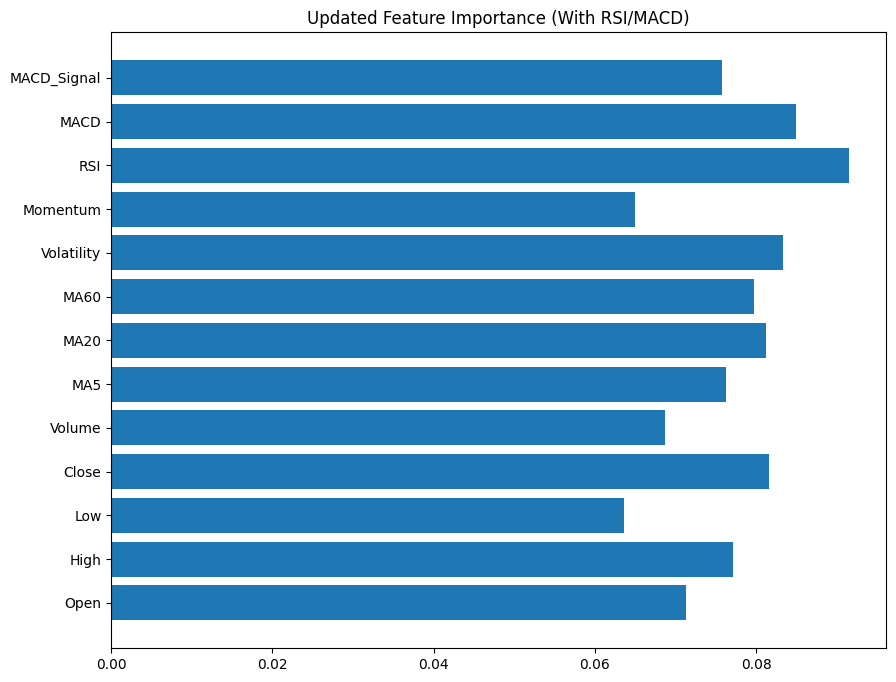

In [ ]:
# -----------------------------------------------------------------------------
# [업그레이드] Step 2-1. INTP의 무기: 기술적 지표(RSI, MACD) 추가 (Your Twist)
# -----------------------------------------------------------------------------
print("2-1. 기술적 지표(RSI, MACD)를 추가합니다...")

# 1. RSI (상대강도지수) 계산 함수
def compute_RSI(data, window=14):
    diff = data.diff(1).dropna()
    gain = 0 * diff
    loss = 0 * diff
    gain[diff > 0] = diff[diff > 0]
    loss[diff < 0] = -diff[diff < 0]
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / (avg_loss + 1e-10) # 0으로 나누기 방지
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = compute_RSI(df['Close'])

# 2. MACD (이동평균 수렴확산) 계산
k = df['Close'].ewm(span=12, adjust=False, min_periods=12).mean() # 단기
d = df['Close'].ewm(span=26, adjust=False, min_periods=26).mean() # 장기
df['MACD'] = k - d
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False, min_periods=9).mean()

# 결측치 제거 (지표 계산하느라 생긴 앞부분 NaN)
df = df.dropna()

# -----------------------------------------------------------------------------
# [업그레이드] Step 3. 정답지 수정 (논문 로직 적용: Threshold)
# -----------------------------------------------------------------------------
print("3. 논문의 핵심 로직(Threshold)을 적용합니다...")

# 논문에서는 0.7%를 썼지만, 데이터 손실을 줄이기 위해 우리는 0.2%로 타협해봅시다.
# 내일 종가가 오늘보다 0.2% 이상 오르면 1, -0.2% 이하로 떨어지면 0, 그 사이는 '삭제'
threshold = 0.002

df['Return'] = (df['Close'].shift(-1) - df['Close']) / df['Close']

# 확실한 상승/하락만 남기기 (박스권 제거)
df_filtered = df[ (df['Return'] > threshold) | (df['Return'] < -threshold) ].copy()

# 정답 라벨링 (상승: 1, 하락: 0)
df_filtered['Target'] = np.where(df_filtered['Return'] > 0, 1, 0)

print(f"전체 데이터: {len(df)}개 -> 필터링 후 데이터: {len(df_filtered)}개 (박스권 제외됨)")

# 학습 데이터 재설정
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'MA60', 'Volatility', 'Momentum', 'RSI', 'MACD', 'MACD_Signal']
X = df_filtered[features]
y = df_filtered['Target']

# 다시 학습 및 평가 진행 (기존 코드의 Step 4, 5 재실행 필요)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n[업그레이드 결과] 모델 정확도: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))

# 중요도 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.barh(features, model.feature_importances_)
plt.title("Updated Feature Importance (With RSI/MACD)")
plt.show()

3. XGBoost 모델 학습을 시작합니다...

4. 최종 결과 리포트
모델 정확도(Accuracy): 50.13%
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.47      0.48      0.47       358
           1       0.53      0.52      0.53       410

    accuracy                           0.50       768
   macro avg       0.50      0.50      0.50       768
weighted avg       0.50      0.50      0.50       768



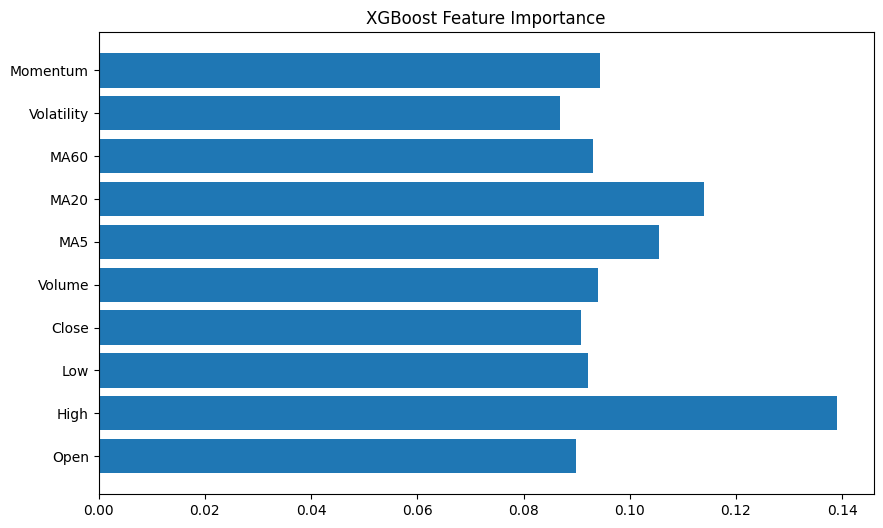

In [ ]:
# ---------------------------------------------------------
# Step 3. 정답지 만들기 (Labeling)
# ---------------------------------------------------------
# 내일 종가가 오늘 종가보다 높으면 1, 아니면 0
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

# 학습에 사용할 변수들 정의
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'MA60', 'Volatility', 'Momentum']

# [디버깅] 실제로 이 컬럼들이 있는지 확인하고 넣습니다.
missing_cols = [col for col in features if col not in df.columns]
if missing_cols:
    print(f"Error: 다음 컬럼이 생성되지 않았습니다 -> {missing_cols}")
else:
    X = df[features]
    y = df['Target']

    # 데이터 분리 (시계열이므로 섞지 않음)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # ---------------------------------------------------------
    # Step 4. 모델 학습 (XGBoost)
    # ---------------------------------------------------------
    print("3. XGBoost 모델 학습을 시작합니다...")
    model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
    model.fit(X_train, y_train)

    # ---------------------------------------------------------
    # Step 5. 결과 평가
    # ---------------------------------------------------------
    print("\n4. 최종 결과 리포트")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"모델 정확도(Accuracy): {accuracy * 100:.2f}%")
    print("-" * 50)
    print(classification_report(y_test, y_pred))

    # 중요도 시각화
    plt.figure(figsize=(10, 6))
    plt.barh(features, model.feature_importances_)
    plt.title("XGBoost Feature Importance")
    plt.show()

3. 절대 가격을 제거하고, 비율(Ratio) 변수로 변환합니다...
학습에 사용할 변수 목록 (가격 제외): ['RSI', 'MACD', 'Volatility', 'Momentum', 'Disparity_5', 'Disparity_20', 'Disparity_60', 'Volume_Chg']
4. 튜닝된 XGBoost 모델 학습 시작...

[최종 결과 리포트]
모델 정확도(Accuracy): 50.63%
              precision    recall  f1-score   support

           0       0.44      0.35      0.39       250
           1       0.54      0.64      0.59       307

    accuracy                           0.51       557
   macro avg       0.49      0.49      0.49       557
weighted avg       0.50      0.51      0.50       557



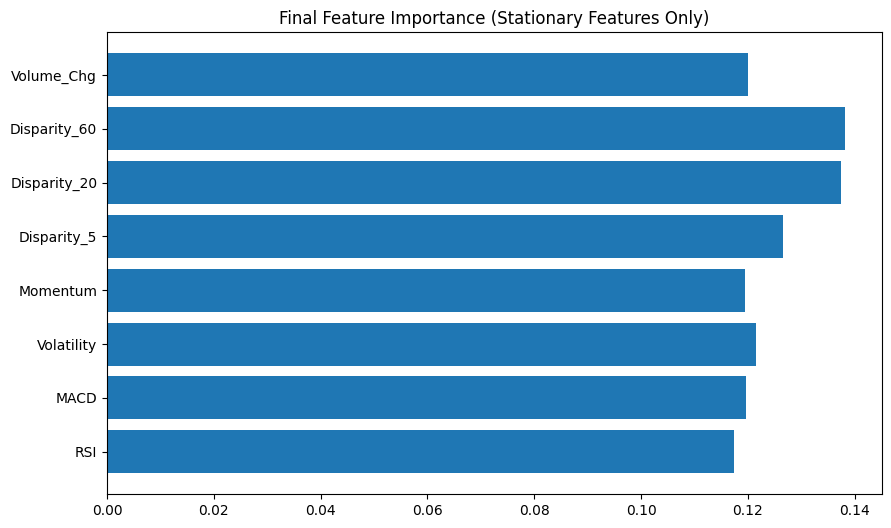

In [ ]:
# -----------------------------------------------------------------------------
# [Final Step] "가격"을 버리고 "비율"로 승부한다 (Stationarity 적용)
# -----------------------------------------------------------------------------
print("3. 절대 가격을 제거하고, 비율(Ratio) 변수로 변환합니다...")

# 1. 이격도 (Disparity): 이동평균선 대비 현재 주가 위치
# 주가가 올라도 이 비율은 1.0~1.1 사이를 왔다갔다 하므로 학습이 잘 됩니다.
df['Disparity_5'] = df['Close'] / df['MA5']
df['Disparity_20'] = df['Close'] / df['MA20']
df['Disparity_60'] = df['Close'] / df['MA60']

# 2. 거래량 변화율 (Volume Ratio)
# 절대 거래량이 아니라, 어제 대비 거래량이 얼마나 터졌는지?
df['Volume_Chg'] = df['Volume'] / df['Volume'].shift(1)

# 3. 결측치 제거
df = df.dropna()

# -----------------------------------------------------------------------------
# [Threshold 전략 수정]
# 데이터가 너무 줄어들면 학습이 안 되므로, Threshold를 제거하고 전체 데이터를 씁니다.
# -----------------------------------------------------------------------------
df['Return'] = (df['Close'].shift(-1) - df['Close']) / df['Close']
df['Target'] = np.where(df['Return'] > 0, 1, 0) # 0보다 크면 상승, 아니면 하락

# [핵심] 절대 가격 변수(Open, Close 등)는 과감히 버립니다.
# 오직 0~100 사이의 지표(RSI)나 비율(이격도)만 남깁니다.
features = [
    'RSI',                # 기술적 지표 (0~100)
    'MACD',               # 추세 지표
    'Volatility',         # 변동성
    'Momentum',           # 모멘텀
    'Disparity_5',        # 5일 이격도
    'Disparity_20',       # 20일 이격도
    'Disparity_60',       # 60일 이격도
    'Volume_Chg'          # 거래량 변화율
]

print(f"학습에 사용할 변수 목록 (가격 제외): {features}")

X = df[features]
y = df['Target']

# 데이터 분리 (최근 15%만 테스트로 사용 - 최근 장세 반영)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

# 모델 학습 (XGBoost 파라미터 튜닝: 과적합 방지)
# max_depth를 3으로 줄여서 모델을 단순하게 만듭니다.
print("4. 튜닝된 XGBoost 모델 학습 시작...")
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,         # 깊이를 얕게 하여 일반화 성능 향상
    subsample=0.8,       # 데이터의 80%만 무작위로 사용하여 학습 (과적합 방지)
    colsample_bytree=0.8,# 변수의 80%만 무작위로 사용
    random_state=42
)
model.fit(X_train, y_train)

# 결과 평가
print("\n[최종 결과 리포트]")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"모델 정확도(Accuracy): {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))

# 중요도 시각화
plt.figure(figsize=(10, 6))
plt.barh(features, model.feature_importances_)
plt.title("Final Feature Importance (Stationary Features Only)")
plt.show()

5. 노이즈(보합장)를 제거하고 확실한 추세만 학습합니다...
전체 데이터: 3708개 -> 노이즈 제거 후: 2792개

[최종 하이브리드 결과 리포트]
모델 정확도(Accuracy): 49.40%
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.40      0.32      0.36       182
           1       0.55      0.62      0.58       237

    accuracy                           0.49       419
   macro avg       0.47      0.47      0.47       419
weighted avg       0.48      0.49      0.48       419



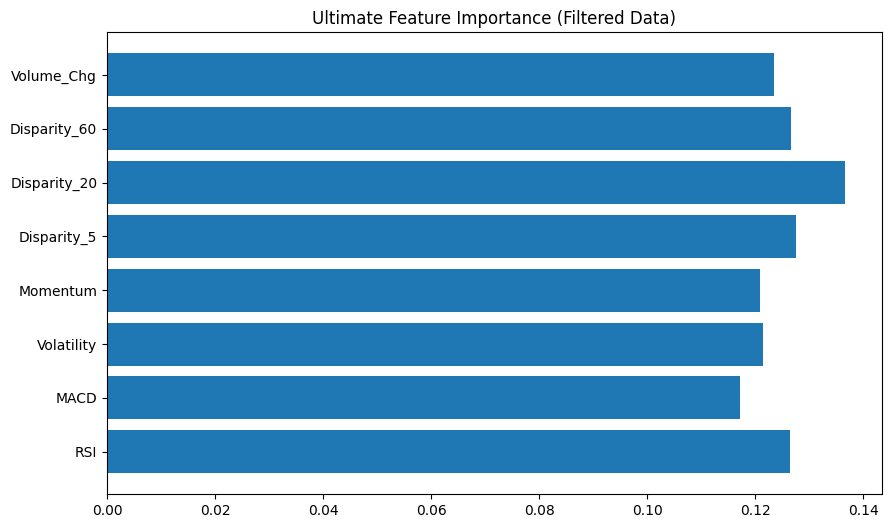

In [ ]:
# -----------------------------------------------------------------------------
# [Ultimate Step] 정상성(Stationarity) + 노이즈 제거(Threshold) = 퀀트의 정석
# -----------------------------------------------------------------------------
print("5. 노이즈(보합장)를 제거하고 확실한 추세만 학습합니다...")

# 1. 등락률 계산
df['Return'] = (df['Close'].shift(-1) - df['Close']) / df['Close']

# 2. [핵심] Threshold 적용 (황희수 논문의 논리 복원)
# 0.25% 이상 오르거나 내린 날만 살리고, 나머지는 버립니다.
# 데이터가 줄어들지만, 모델의 '확신'은 올라갑니다.
threshold = 0.0025

# 조건: 절대값 기준으로 0.25% 이상 움직인 날만 필터링
df_filtered = df[np.abs(df['Return']) > threshold].copy()

print(f"전체 데이터: {len(df)}개 -> 노이즈 제거 후: {len(df_filtered)}개")

# 3. 정답 라벨링 (상승: 1, 하락: 0)
df_filtered['Target'] = np.where(df_filtered['Return'] > 0, 1, 0)

# 4. 학습 변수 (이미 검증된 이격도 중심)
features = [
    'RSI', 'MACD', 'Volatility', 'Momentum',
    'Disparity_5', 'Disparity_20', 'Disparity_60', 'Volume_Chg'
]

X = df_filtered[features]
y = df_filtered['Target']

# 데이터 분리 (최근 15% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

# 5. 모델 학습 (파라미터 유지)
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# 6. 결과 평가
print("\n[최종 하이브리드 결과 리포트]")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"모델 정확도(Accuracy): {accuracy * 100:.2f}%")
print("-" * 50)
print(classification_report(y_test, y_pred))

# 중요도 시각화
plt.figure(figsize=(10, 6))
plt.barh(features, model.feature_importances_)
plt.title("Ultimate Feature Importance (Filtered Data)")
plt.show()

6. 예측 기간을 '내일'에서 '5일 후(주간 추세)'로 변경합니다...
전체 데이터: 3708개 -> 주간 추세 필터링 후: 2351개

[주간 추세(Weekly) 예측 결과 리포트]
모델 정확도(Accuracy): 49.58%
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.31      0.26      0.28       135
           1       0.58      0.64      0.61       218

    accuracy                           0.50       353
   macro avg       0.45      0.45      0.45       353
weighted avg       0.48      0.50      0.49       353



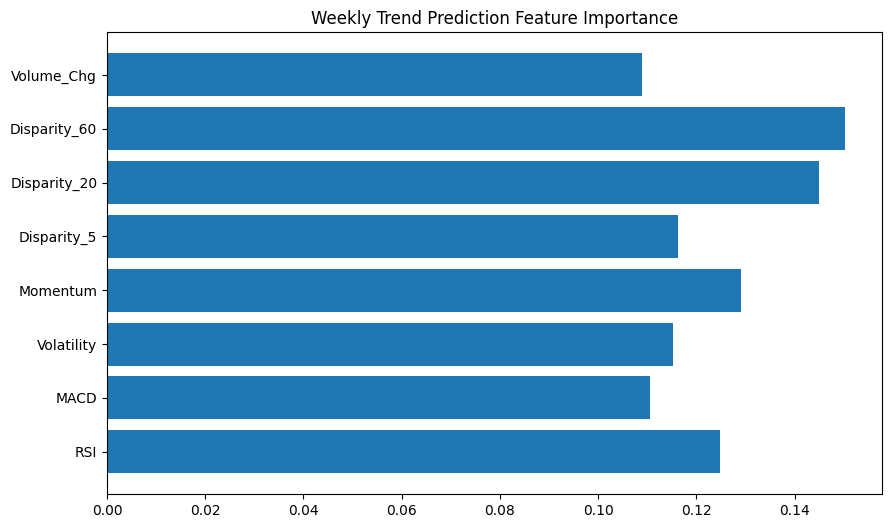

In [ ]:
# -----------------------------------------------------------------------------
# [Pivot Strategy] Daily(노이즈) -> Weekly(추세) 예측으로 전환
# -----------------------------------------------------------------------------
print("6. 예측 기간을 '내일'에서 '5일 후(주간 추세)'로 변경합니다...")

# 1. [핵심 변경] 5일 후의 종가와 비교 (Weekly Return)
# shift(-1) -> shift(-5)
df['Return'] = (df['Close'].shift(-5) - df['Close']) / df['Close']

# 2. Threshold 재설정 (주간 변동성은 더 크므로 1%로 설정)
# 일주일 동안 1% 이상 오르거나 내린 '확실한 추세'만 학습합니다.
threshold = 0.01

df_filtered = df[np.abs(df['Return']) > threshold].copy()

print(f"전체 데이터: {len(df)}개 -> 주간 추세 필터링 후: {len(df_filtered)}개")

# 3. 정답 라벨링
df_filtered['Target'] = np.where(df_filtered['Return'] > 0, 1, 0)

# 4. 변수는 그대로 사용 (이격도, RSI는 추세 예측에 더 강력함)
features = [
    'RSI', 'MACD', 'Volatility', 'Momentum',
    'Disparity_5', 'Disparity_20', 'Disparity_60', 'Volume_Chg'
]

X = df_filtered[features]
y = df_filtered['Target']

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

# 5. 모델 학습 (파라미터 동일)
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# 6. 결과 평가
print("\n[주간 추세(Weekly) 예측 결과 리포트]")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"모델 정확도(Accuracy): {accuracy * 100:.2f}%")
print("-" * 50)
print(classification_report(y_test, y_pred))

# 중요도 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(features, model.feature_importances_)
plt.title("Weekly Trend Prediction Feature Importance")
plt.show()